Data Gathering

In [1]:
import pandas as pd
df = pd.read_csv("311_Service_Requests.csv")
df.head()

/tmp/ipykernel_2078/1316942104.py:2: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311_Service_Requests.csv")


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [2]:
df.shape

(364558, 53)

In [3]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unique Key                      364558 non-null  int64  
 1   Created Date                    364558 non-null  object 
 2   Closed Date                     362177 non-null  object 
 3   Agency                          364558 non-null  object 
 4   Agency Name                     364558 non-null  object 
 5   Complaint Type                  364558 non-null  object 
 6   Descriptor                      358057 non-null  object 
 7   Location Type                   364425 non-null  object 
 8   Incident Zip                    361560 non-null  float64
 9   Incident Address                312859 non-null  object 
 10  Street Name                     312859 non-null  object 
 11  Cross Street 1                  307370 non-null  object 
 12  Cross Street 2  

Data Preprocessing

In [5]:
df = df[['Created Date', 'Complaint Type', 'Descriptor', 'Borough', 'Latitude', 'Longitude']]

In [6]:
df.rename(columns = {'Created Date': 'date', 'Complaint Type' : 'category', 'Descriptor' : 'complaint', 'Borough' : 'location'}, inplace=True)

In [7]:
df = df.dropna()

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.to_csv("clean_complaints.csv", index=False)

In [10]:
df.head()

,date,category,complaint,location,Latitude,Longitude
0,12/31/2015 11:59:45 PM,Noise - Street/Sidewalk,Loud Music/Party,MANHATTAN,40.865682,-73.923501
1,12/31/2015 11:59:44 PM,Blocked Driveway,No Access,QUEENS,40.775945,-73.915094
2,12/31/2015 11:59:29 PM,Blocked Driveway,No Access,BRONX,40.870325,-73.888525
3,12/31/2015 11:57:46 PM,Illegal Parking,Commercial Overnight Parking,BRONX,40.835994,-73.828379
4,12/31/2015 11:56:58 PM,Illegal Parking,Blocked Sidewalk,QUEENS,40.733060,-73.874170


In [11]:
df.shape

(354101, 6)

In [12]:
df.isnull().sum()

,0
date,0
category,0
complaint,0
location,0
Latitude,0
Longitude,0


Perform EDA

In [13]:
df.head()

,date,category,complaint,location,Latitude,Longitude
0,12/31/2015 11:59:45 PM,Noise - Street/Sidewalk,Loud Music/Party,MANHATTAN,40.865682,-73.923501
1,12/31/2015 11:59:44 PM,Blocked Driveway,No Access,QUEENS,40.775945,-73.915094
2,12/31/2015 11:59:29 PM,Blocked Driveway,No Access,BRONX,40.870325,-73.888525
3,12/31/2015 11:57:46 PM,Illegal Parking,Commercial Overnight Parking,BRONX,40.835994,-73.828379
4,12/31/2015 11:56:58 PM,Illegal Parking,Blocked Sidewalk,QUEENS,40.733060,-73.874170


In [14]:
df.describe()

,Latitude,Longitude
count,354101.000000,354101.000000
mean,40.724787,-73.924400
std,0.082259,0.079404
min,40.499040,-74.254937
25%,40.667979,-73.971468
50%,40.717707,-73.929824
75%,40.778610,-73.873072
max,40.912869,-73.700715


In [15]:
df['category'].value_counts()

,count
category,
Blocked Driveway,100503
Illegal Parking,91102
Noise - Street/Sidewalk,50837
Noise - Commercial,43655
Derelict Vehicle,21432
Noise - Vehicle,19127
Animal Abuse,10503
Traffic,5170
Vending,4165


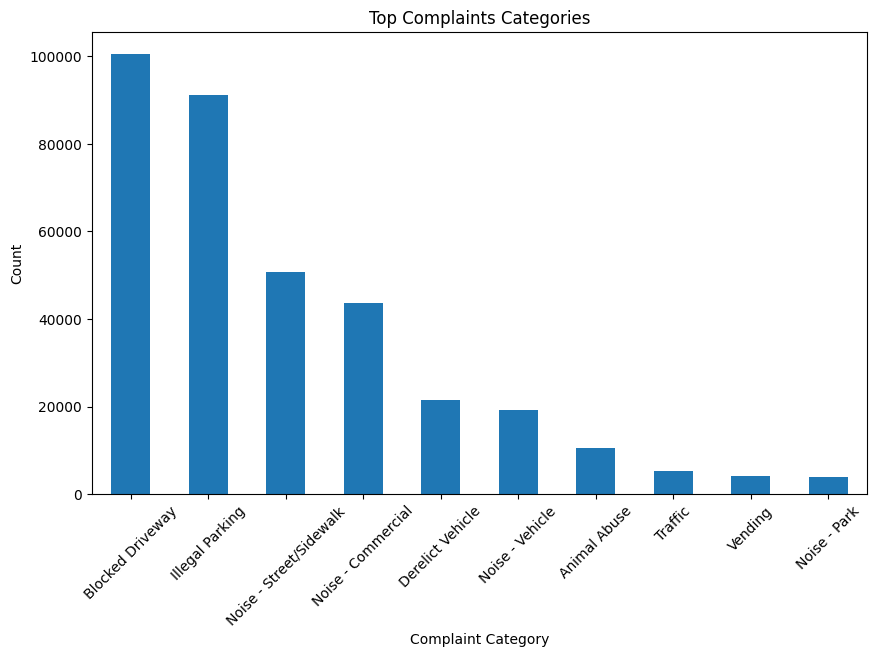

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df['category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Complaints Categories")
plt.xlabel("Complaint Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("category_distribution.png")
plt.show()

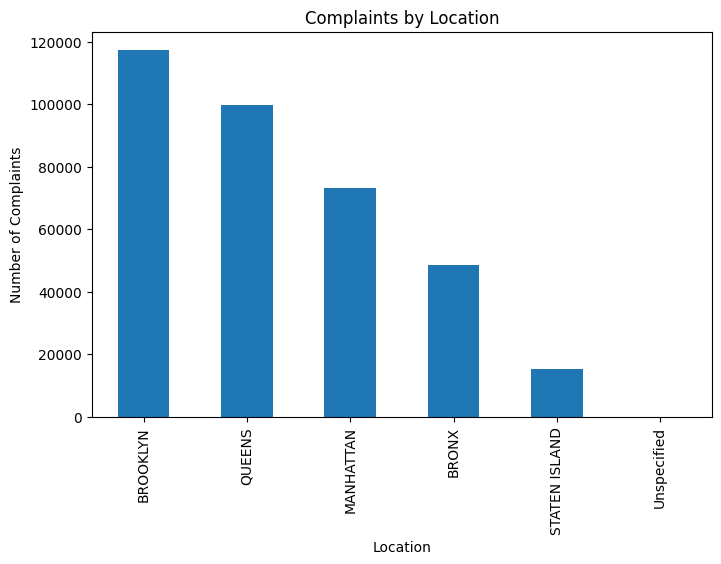

In [17]:
plt.figure(figsize=(8,5))
df['location'].value_counts().plot(kind='bar')
plt.title("Complaints by Location")
plt.xlabel("Location")
plt.ylabel("Number of Complaints")
plt.savefig("location_distribution.png")
plt.show()

In [18]:
df['complaint'].value_counts().head(10)

,count
complaint,
No Access,75624
Loud Music/Party,68734
Posted Parking Sign Violation,26833
Partial Access,24879
Loud Talking,23468
With License Plate,21432
Blocked Hydrant,19726
Commercial Overnight Parking,14633
Blocked Sidewalk,13621


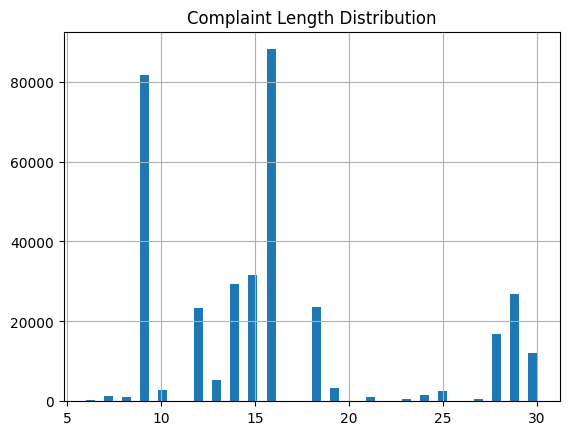

In [19]:
df['complaint_length'] = df['complaint'].apply(len)
df['complaint_length'].hist(bins=50)
plt.title("Complaint Length Distribution")
plt.savefig("complaint_length.png")
plt.show()

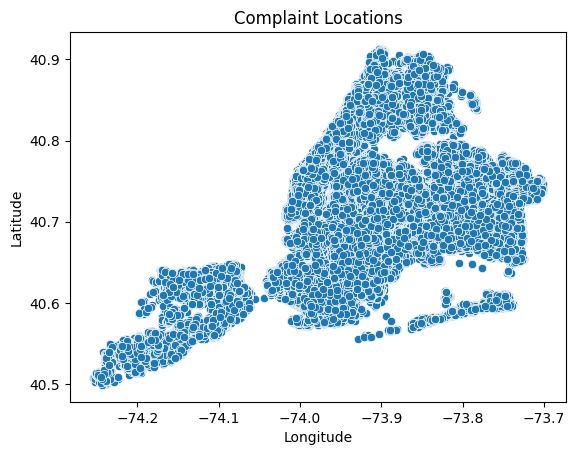

In [20]:
import seaborn as sns

sns.scatterplot(x=df['Longitude'], y=df['Latitude'])
plt.title("Complaint Locations")
plt.show()

In [21]:
df.isnull().sum()

,0
date,0
category,0
complaint,0
location,0
Latitude,0
Longitude,0
complaint_length,0


In [22]:
df.duplicated().sum()

np.int64(0)

NLP( text processing )

In [23]:
import re

def clean_text(text):
  text = text.lower()    #for lowercase
  text = re.sub(r'[^a-zA-Z\s]', '', text)   #remove special characters
  return text

df['clean_complaint'] = df['complaint'].apply(clean_text)
df[['complaint', 'clean_complaint']].head()

,complaint,clean_complaint
0,Loud Music/Party,loud musicparty
1,No Access,no access
2,No Access,no access
3,Commercial Overnight Parking,commercial overnight parking
4,Blocked Sidewalk,blocked sidewalk


Stopwords Removal

In [24]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
  words = text.split()
  words = [word for word in words if word not in stop_words]
  return " ".join(words)

df['clean_complaint'] = df['clean_complaint'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [25]:
df[['complaint', 'clean_complaint']].head()

,complaint,clean_complaint
0,Loud Music/Party,loud musicparty
1,No Access,access
2,No Access,access
3,Commercial Overnight Parking,commercial overnight parking
4,Blocked Sidewalk,blocked sidewalk
